In [1]:
# --- GPU selection (set BEFORE importing torch in runtime) ---
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"   # use physical GPU:0 only

# After this, PyTorch will see physical GPU:1 as cuda:0.


# HSCD Binary Square Classifier v8: ConvNeXt-Base + Masked Gated Attention Pooling

This notebook trains a full raw-image binary classifier for the Hebrew Script Classification Dataset (HSCD).

Key design choices:
- No patch cropping.
- No aggressive downscaling of the full text region.
- Variable-size images are handled by dynamic padding inside each batch.
- A valid-token mask prevents attention from using padded regions.
- Training-only image-mode augmentation randomly uses RGB, 3-channel grayscale, or 3-channel binarized images.
- The model predicts whether each raw image is square or non-square.
- Early ConvNeXt stem/stages are frozen using the actual timm `FeatureListNet` module names.
- The best checkpoint is selected by validation balanced accuracy.

Architecture:

```text
variable-size RGB image
    -> ConvNeXt-Base fully convolutional backbone
    -> stride-32 spatial feature map
    -> masked gated attention pooling
    -> MLP classifier
    -> 2 logits
```


In [2]:
# Optional: install missing packages in Colab
# Uncomment if needed.
# !pip install -q timm scikit-learn tqdm pandas matplotlib pillow


In [3]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import timm
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report


/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory GB:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Device: cuda
GPU: NVIDIA A40
Memory GB: 44.35


## 1. Configuration

Set `RAW_IMAGES_DIR` to the folder that contains the raw HSCD images:

```text
hscd/images
```

The notebook supports filenames that follow either raw-image or cropped-region format:

```text
[manuscript_name]_[IE...]_[P...]_[FL...]_[script_type]_[script_mode].jpg
[manuscript_name]_[IE...]_[P...]_[FL...]_[script_type]_[script_mode]_[region_index].jpg
```


In [ ]:
RAW_IMAGES_DIR = Path('hscd/images')
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
BALANCE_TRAIN_CLASSES = True
BALANCE_VAL_CLASSES = True

CLASS_NAMES = ['non_square', 'square']

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
IMG_CROP_MAX_HEIGHT = 2500  # crop, do not resize, images taller than this
IMG_CROP_MAX_WIDTH = 2500   # crop, do not resize, images wider than this
BATCH_SIZE = 4            # raw full images are much larger than cropped regions; raise only if memory allows
NUM_WORKERS = 4
EPOCHS = 40
PATIENCE = 5

BACKBONE_NAME = 'convnext_base.fb_in22k_ft_in1k'
BACKBONE_OUT_INDEX = 3   # ConvNeXt feature stage: 0=stride4, 1=stride8, 2=stride16, 3=stride32
PRETRAINED = True

BACKBONE_LR = 5e-6
HEAD_LR = 5e-5
WEIGHT_DECAY = 0.1
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 3
GRAD_CLIP_NORM = 1.0

USE_AMP = True
OUT_DIR = Path('hsmc_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DROPOUT = 0.3
FREEZE_BACKBONE_STAGES_UNTIL = 2

# Training-only multi-scale crop. A scale is chosen, then a random crop is sampled at that scale.
TRAIN_RANDOM_SCALE_FACTORS = [0.5, 0.75, 1.0, 1.25, 1.5]

# Training-only image-mode augmentation weights. All outputs remain 3-channel RGB tensors.
TRAIN_RGB_WEIGHT = 0.5
TRAIN_GRAYSCALE_WEIGHT = 0.25
TRAIN_BINARIZED_WEIGHT = 0.25


In [6]:
def parse_hscd_filename(path):
    """Parse raw HSCD image or cropped-region filename into metadata and binary label."""
    stem = Path(path).stem
    parts = stem.split('_')
    if len(parts) < 6:
        raise ValueError(f'Unexpected filename format: {Path(path).name}')

    has_region_index = parts[-1].isdigit()
    if has_region_index:
        script_type = parts[-3].lower()
        script_mode = parts[-2].lower()
        region_index = parts[-1]
        image_kind = 'cropped_region'
    else:
        script_type = parts[-2].lower()
        script_mode = parts[-1].lower()
        region_index = None
        image_kind = 'raw_image'

    source_label_name = f'{script_type}_{script_mode}'
    label_name = 'square' if script_mode == 'square' else 'non_square'
    if label_name not in class_to_idx:
        raise ValueError(f'Unknown binary class {label_name} from file {Path(path).name}')

    if len(parts) >= 4 and parts[1].startswith('IE') and parts[2].startswith('P') and parts[3].startswith('FL'):
        manuscript_name = parts[0]
        page_name = '_'.join(parts[:3])
        region_name = '_'.join(parts[:4])
    elif has_region_index:
        page_name = parts[-4]
        region_name = '_'.join(parts[:-3])
        manuscript_name = '_'.join(parts[:-4])
    else:
        page_name = '_'.join(parts[:-2])
        region_name = page_name
        manuscript_name = parts[0]

    return {
        'path': str(path),
        'manuscript_name': manuscript_name,
        'page_name': page_name,
        'region_name': region_name,
        'script_type': script_type,
        'script_mode': script_mode,
        'region_index': region_index,
        'image_kind': image_kind,
        'source_label_name': source_label_name,
        'label_name': label_name,
        'label': class_to_idx[label_name],
    }


def build_dataframe(image_dir):
    exts = ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']
    paths = []
    for ext in exts:
        paths.extend(sorted(Path(image_dir).rglob(ext)))
    rows = [parse_hscd_filename(p) for p in paths]
    return pd.DataFrame(rows)

def split_by_manuscript(df, val_fraction=0.15, test_fraction=0.15, seed=SEED):
    manuscripts = np.array(sorted(df.manuscript_name.unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(manuscripts)

    n_total = len(manuscripts)
    n_test = max(1, int(round(n_total * test_fraction)))
    n_val = max(1, int(round(n_total * val_fraction)))

    test_ms = set(manuscripts[:n_test])
    val_ms = set(manuscripts[n_test:n_test + n_val])
    train_ms = set(manuscripts[n_test + n_val:])

    train_df = df[df.manuscript_name.isin(train_ms)].reset_index(drop=True)
    val_df = df[df.manuscript_name.isin(val_ms)].reset_index(drop=True)
    test_df = df[df.manuscript_name.isin(test_ms)].reset_index(drop=True)
    return train_df, val_df, test_df


def balance_dataframe(df, class_names=CLASS_NAMES, seed=SEED, split_name='split'):
    counts = df.label_name.value_counts().reindex(class_names).fillna(0).astype(int)
    if (counts == 0).any():
        missing = counts[counts == 0].index.tolist()
        raise ValueError(f'Cannot balance {split_name} set because these classes are missing: {missing}')

    target_per_class = int(counts.min())
    parts = []
    for label_name in class_names:
        class_df = df[df.label_name.eq(label_name)]
        if len(class_df) > target_per_class:
            class_df = class_df.sample(n=target_per_class, random_state=seed + class_to_idx[label_name])
        parts.append(class_df)

    balanced_df = pd.concat(parts, axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df, counts, target_per_class


all_df = build_dataframe(RAW_IMAGES_DIR)
raw_train_df, raw_val_df, test_df = split_by_manuscript(all_df, VAL_FRACTION, TEST_FRACTION, SEED)
if BALANCE_TRAIN_CLASSES:
    train_df, raw_train_counts, train_target_per_class = balance_dataframe(raw_train_df, CLASS_NAMES, SEED, split_name='train')
else:
    train_df = raw_train_df.copy().reset_index(drop=True)
    raw_train_counts = train_df.label_name.value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    train_target_per_class = None

if BALANCE_VAL_CLASSES:
    val_df, raw_val_counts, val_target_per_class = balance_dataframe(raw_val_df, CLASS_NAMES, SEED + 1000, split_name='validation')
else:
    val_df = raw_val_df.copy().reset_index(drop=True)
    raw_val_counts = val_df.label_name.value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    val_target_per_class = None

print('All images:', len(all_df), 'manuscripts:', all_df.manuscript_name.nunique())

print('Raw train images before balancing:', len(raw_train_df), 'manuscripts:', raw_train_df.manuscript_name.nunique())
print('Balanced train images:', len(train_df), 'manuscripts:', train_df.manuscript_name.nunique())
print('Raw val images before balancing:', len(raw_val_df), 'manuscripts:', raw_val_df.manuscript_name.nunique())
print('Balanced val images:', len(val_df), 'manuscripts:', val_df.manuscript_name.nunique())
print('Test images: ', len(test_df), 'manuscripts:', test_df.manuscript_name.nunique())

print('Image kinds:')
display(all_df.image_kind.value_counts().to_frame('images'))

print('Raw train binary class counts before balancing:')
display(raw_train_counts.to_frame('images'))

print('Balanced train binary class counts:')
display(train_df.label_name.value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame('images'))
print('Train target per class:', train_target_per_class)

print('Raw val binary class counts before balancing:')
display(raw_val_counts.to_frame('images'))

print('Balanced val binary class counts:')
display(val_df.label_name.value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame('images'))
print('Val target per class:', val_target_per_class)

print('Balanced train source class counts:')
display(train_df.source_label_name.value_counts().sort_index().to_frame('images'))


All images: 5215 manuscripts: 1741
Raw train images before balancing: 3652 manuscripts: 1219
Balanced train images: 1656 manuscripts: 883
Raw val images before balancing: 782 manuscripts: 261
Balanced val images: 318 manuscripts: 172
Test images:  781 manuscripts: 261
Image kinds:


,images
image_kind,
raw_image,5215


Raw train binary class counts before balancing:


,images
label_name,
non_square,2824
square,828


Balanced train binary class counts:


...

,images
label_name,
non_square,623
square,159


Balanced val binary class counts:


,images
label_name,
non_square,159
square,159


Val target per class: 159
Balanced train source class counts:


,images
source_label_name,
ashkenazic_cursive,5
ashkenazic_semicursive,120
ashkenazic_square,255
byzantine_semicursive,71
byzantine_square,24
italian_cursive,6
italian_semicursive,249
italian_square,60
oriental_semicursive,49


In [7]:
# Leakage checks at manuscript level
train_ms = set(train_df.manuscript_name)
val_ms = set(val_df.manuscript_name)
test_ms = set(test_df.manuscript_name)

print('train/val manuscript overlap:', len(train_ms & val_ms))
print('train/test manuscript overlap:', len(train_ms & test_ms))
print('val/test manuscript overlap:', len(val_ms & test_ms))


train/val manuscript overlap: 0
train/test manuscript overlap: 0
val/test manuscript overlap: 0


## 2. Dataset and variable-size batching

Images are not resized to a fixed global size for evaluation. Training samples choose a random scale from `TRAIN_RANDOM_SCALE_FACTORS`, then take a random crop capped by `IMG_CROP_MAX_HEIGHT` and `IMG_CROP_MAX_WIDTH`. Train-eval, validation, test, and inference use an unscaled center crop capped by the same size. The batch collate function pads images to the largest height and width in the batch and returns a pixel-level validity mask.


In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def crop_to_max_size_if_needed(img, max_height=None, max_width=None, random_crop=False):
    w, h = img.size
    crop_h = h if max_height is None else min(h, int(max_height))
    crop_w = w if max_width is None else min(w, int(max_width))

    if crop_h == h and crop_w == w:
        return img

    if random_crop:
        left = random.randint(0, w - crop_w) if crop_w < w else 0
        top = random.randint(0, h - crop_h) if crop_h < h else 0
    else:
        left = int(round((w - crop_w) / 2)) if crop_w < w else 0
        top = int(round((h - crop_h) / 2)) if crop_h < h else 0
    return img.crop((left, top, left + crop_w, top + crop_h))


def otsu_threshold(gray):
    hist = np.bincount(gray.reshape(-1), minlength=256).astype(np.float64)
    total = gray.size
    values = np.arange(256, dtype=np.float64)

    weight_bg = np.cumsum(hist)
    weight_fg = total - weight_bg
    sum_bg = np.cumsum(hist * values)
    sum_fg = sum_bg[-1] - sum_bg

    valid = (weight_bg > 0) & (weight_fg > 0)
    between = np.zeros(256, dtype=np.float64)
    mean_bg = np.zeros(256, dtype=np.float64)
    mean_fg = np.zeros(256, dtype=np.float64)
    mean_bg[valid] = sum_bg[valid] / weight_bg[valid]
    mean_fg[valid] = sum_fg[valid] / weight_fg[valid]
    between[valid] = weight_bg[valid] * weight_fg[valid] * (mean_bg[valid] - mean_fg[valid]) ** 2
    return int(np.argmax(between))


def to_three_channel_grayscale(img):
    return img.convert('L').convert('RGB')


def to_three_channel_binarized(img):
    gray = np.asarray(img.convert('L'), dtype=np.uint8)
    threshold = otsu_threshold(gray)
    binary = np.where(gray <= threshold, 0, 255).astype(np.uint8)
    return Image.fromarray(binary).convert('RGB')


def train_image_mode_augment(img):
    mode = random.choices(
        ['rgb', 'grayscale', 'binarized'],
        weights=[TRAIN_RGB_WEIGHT, TRAIN_GRAYSCALE_WEIGHT, TRAIN_BINARIZED_WEIGHT],
        k=1,
    )[0]
    if mode == 'grayscale':
        return to_three_channel_grayscale(img)
    if mode == 'binarized':
        return to_three_channel_binarized(img)
    return img.convert('RGB')



def random_scaled_crop_to_max_size(img, scale_factors, max_height=None, max_width=None):
    scale = float(random.choice(scale_factors))
    w, h = img.size
    scaled_w = max(1, int(round(w * scale)))
    scaled_h = max(1, int(round(h * scale)))

    crop_w = scaled_w if max_width is None else min(scaled_w, int(max_width))
    crop_h = scaled_h if max_height is None else min(scaled_h, int(max_height))

    left_scaled = random.randint(0, scaled_w - crop_w) if crop_w < scaled_w else 0
    top_scaled = random.randint(0, scaled_h - crop_h) if crop_h < scaled_h else 0

    if scale == 1.0:
        return img.crop((left_scaled, top_scaled, left_scaled + crop_w, top_scaled + crop_h))

    left = left_scaled / scale
    top = top_scaled / scale
    right = (left_scaled + crop_w) / scale
    bottom = (top_scaled + crop_h) / scale
    crop = img.crop((left, top, right, bottom))
    return crop.resize((crop_w, crop_h), Image.BICUBIC)


def train_augment(img):
    # Conservative augmentations: preserve paleographic morphology.
    if random.random() < 0.5:
        angle = random.uniform(-2.0, 2.0)
        img = TF.rotate(img, angle, interpolation=InterpolationMode.BICUBIC, fill=255)
    if random.random() < 0.5:
        scale = random.uniform(0.95, 1.05)
        shear = random.uniform(-1.0, 1.0)
        img = TF.affine(img, angle=0.0, translate=(0, 0), scale=scale, shear=[shear, 0.0], interpolation=InterpolationMode.BICUBIC, fill=255)
    if random.random() < 0.7:
        img = TF.adjust_brightness(img, random.uniform(0.85, 1.15))
        img = TF.adjust_contrast(img, random.uniform(0.85, 1.20))
    if random.random() < 0.25:
        img = TF.adjust_saturation(img, random.uniform(0.85, 1.15))
    img = train_image_mode_augment(img)
    return img


def pil_to_normalized_tensor(img):
    x = TF.to_tensor(img)  # float [0,1], C,H,W
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


class HSCDTextRegionDataset(Dataset):
    def __init__(self, df, train=False, max_height=None, max_width=None):
        self.df = df.reset_index(drop=True)
        self.train = train
        self.max_height = max_height
        self.max_width = max_width

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.path).convert('RGB')
        if self.train:
            img = random_scaled_crop_to_max_size(
                img,
                scale_factors=TRAIN_RANDOM_SCALE_FACTORS,
                max_height=self.max_height,
                max_width=self.max_width,
            )
            img = train_augment(img)
        else:
            img = crop_to_max_size_if_needed(
                img,
                max_height=self.max_height,
                max_width=self.max_width,
                random_crop=False,
            )
        x = pil_to_normalized_tensor(img)
        y = int(row.label)
        return {
            'image': x,
            'label': y,
            'path': row.path,
            'label_name': row.label_name,
            'source_label_name': row.source_label_name,
            'orig_size': (img.height, img.width),
        }


def pad_to_multiple(x, multiple=32):
    return int(math.ceil(x / multiple) * multiple)


def collate_variable_size(batch, pad_multiple=32):
    labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    paths = [b['path'] for b in batch]
    label_names = [b['label_name'] for b in batch]
    source_label_names = [b['source_label_name'] for b in batch]
    sizes = [b['image'].shape[-2:] for b in batch]

    max_h = pad_to_multiple(max(h for h, w in sizes), pad_multiple)
    max_w = pad_to_multiple(max(w for h, w in sizes), pad_multiple)

    images = []
    masks = []
    white = ((torch.ones(3, 1, 1) - IMAGENET_MEAN) / IMAGENET_STD)
    for b in batch:
        x = b['image']
        c, h, w = x.shape
        canvas = white.to(x.dtype).expand(3, max_h, max_w).clone()
        canvas[:, :h, :w] = x
        mask = torch.zeros(max_h, max_w, dtype=torch.bool)
        mask[:h, :w] = True
        images.append(canvas)
        masks.append(mask)

    return {
        'image': torch.stack(images, dim=0),
        'mask': torch.stack(masks, dim=0),
        'label': labels,
        'path': paths,
        'label_name': label_names,
        'source_label_name': source_label_names,
        'size': sizes,
    }

train_ds = HSCDTextRegionDataset(train_df, train=True, max_height=IMG_CROP_MAX_HEIGHT, max_width=IMG_CROP_MAX_WIDTH)
train_eval_ds = HSCDTextRegionDataset(train_df, train=False, max_height=IMG_CROP_MAX_HEIGHT, max_width=IMG_CROP_MAX_WIDTH)
val_ds   = HSCDTextRegionDataset(val_df, train=False, max_height=IMG_CROP_MAX_HEIGHT, max_width=IMG_CROP_MAX_WIDTH)
test_ds  = HSCDTextRegionDataset(test_df, train=False, max_height=IMG_CROP_MAX_HEIGHT, max_width=IMG_CROP_MAX_WIDTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True, collate_fn=collate_variable_size, persistent_workers=NUM_WORKERS > 0)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                               pin_memory=True, collate_fn=collate_variable_size, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                        pin_memory=True, collate_fn=collate_variable_size, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=True, collate_fn=collate_variable_size, persistent_workers=NUM_WORKERS > 0)

batch = next(iter(train_loader))
print(batch['image'].shape, batch['mask'].shape, batch['label'].shape)


torch.Size([4, 3, 2528, 2528]) torch.Size([4, 2528, 2528]) torch.Size([4])


/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (120577872 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (132101370 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (122997960 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (131730925 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:345

## 3. Model: ConvNeXt-Base + masked gated attention pooling

The model extracts a dense spatial feature map. The image mask is downsampled to the feature-map size, so padded tokens are excluded from attention.


In [9]:
def freeze_convnext_early_stages(model, freeze_until=2):
    """Freeze the ConvNeXt stem and the first ``freeze_until`` timm stages."""
    if not hasattr(model, 'backbone'):
        print('Warning: model.backbone not found; skipping freezing.')
        return []

    backbone = model.backbone
    modules_to_freeze = []
    frozen_names = []

    for name in ['stem_0', 'stem_1']:
        if hasattr(backbone, name):
            modules_to_freeze.append(getattr(backbone, name))
            frozen_names.append(name)

    for idx in range(max(0, min(int(freeze_until), 4))):
        name = f'stages_{idx}'
        if hasattr(backbone, name):
            modules_to_freeze.append(getattr(backbone, name))
            frozen_names.append(name)

    if not modules_to_freeze:
        print('Warning: no known timm ConvNeXt modules found; skipping freezing.')
        return []

    for module in modules_to_freeze:
        for p in module.parameters():
            p.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print('Frozen modules:', ', '.join(frozen_names))
    print(f'Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)')
    return frozen_names


In [10]:
class MaskedGatedAttentionPool(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.att_v = nn.Linear(in_dim, hidden_dim)
        self.att_u = nn.Linear(in_dim, hidden_dim)
        self.att_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, feat, mask):
        # feat: B,C,H,W
        # mask: B,H,W bool, valid=True
        b, c, h, w = feat.shape
        x = feat.flatten(2).transpose(1, 2)  # B,N,C
        m = mask.flatten(1)                 # B,N

        a = torch.tanh(self.att_v(x)) * torch.sigmoid(self.att_u(x))
        a = self.att_w(self.dropout(a)).squeeze(-1)  # B,N
        a = a.masked_fill(~m, torch.finfo(a.dtype).min)
        alpha = torch.softmax(a, dim=1)
        z = torch.sum(x * alpha.unsqueeze(-1), dim=1)
        return z, alpha.view(b, h, w)


class HSCDConvNeXtAttention(nn.Module):
    def __init__(self, backbone_name, num_classes=2, pretrained=True, feature_out_index=2, att_hidden=512, dropout=0.2):
        super().__init__()
        feature_out_index = int(feature_out_index)
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(feature_out_index,),
        )
        feat_dim = self.backbone.feature_info.channels()[0]
        self.feature_reduction = self.backbone.feature_info.reduction()[0]
        self.pool = MaskedGatedAttentionPool(feat_dim, hidden_dim=att_hidden, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x, pixel_mask):
        feats = self.backbone(x)[-1]  # B,C,Hf,Wf
        hf, wf = feats.shape[-2:]
        feat_mask = F.interpolate(pixel_mask.float().unsqueeze(1), size=(hf, wf), mode='nearest').squeeze(1).bool()
        z, att_map = self.pool(feats, feat_mask)
        logits = self.classifier(z)
        return logits, att_map


model = HSCDConvNeXtAttention(BACKBONE_NAME, NUM_CLASSES, PRETRAINED, feature_out_index=BACKBONE_OUT_INDEX, dropout=DROPOUT).to(device)
frozen_modules = freeze_convnext_early_stages(model, freeze_until=FREEZE_BACKBONE_STAGES_UNTIL)

backbone_params = []
head_params = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if name.startswith('backbone'):
        backbone_params.append(p)
    else:
        head_params.append(p)

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params, 'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP and torch.cuda.is_available())

print('Backbone params:', round(sum(p.numel() for p in backbone_params) / 1e6, 2), 'M')
print('Head params:', round(sum(p.numel() for p in head_params) / 1e6, 2), 'M')
print('Backbone feature reduction:', model.feature_reduction)


Frozen modules: stem_0, stem_1, stages_0, stages_1
Trainable parameters: 86,447,619 / 88,618,627 (97.55%)
Backbone params: 85.39 M
Head params: 1.05 M
Backbone feature reduction: 32


In [11]:
def make_scheduler(optimizer, total_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = make_scheduler(optimizer, EPOCHS, WARMUP_EPOCHS)


## 4. Training and evaluation utilities


## 5. Train

The checkpoint is selected by validation balanced accuracy.


In [12]:
def train_one_epoch(model, loader, optimizer, scaler, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    n_seen = 0

    pbar = tqdm(loader, desc=f'train epoch {epoch}', leave=False)
    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        masks = batch['mask'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP and torch.cuda.is_available()):
            logits = unwrap_logits(model(images, masks))
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        running_loss += loss.item() * bs
        n_seen += bs
        pbar.set_postfix(loss=f'{running_loss / max(1, n_seen):.4f}')

    return running_loss / max(1, n_seen)


In [13]:
import inspect
print("Active train_one_epoch signature:", inspect.signature(train_one_epoch))
assert len(inspect.signature(train_one_epoch).parameters) == 7, "Wrong train_one_epoch definition is active"


Active train_one_epoch signature: (model, loader, optimizer, scaler, criterion, device, epoch)


In [14]:
def unwrap_logits(output):
    """Return logits tensor from model output. Supports either logits or (logits, auxiliary_outputs)."""
    if isinstance(output, (tuple, list)):
        return output[0]
    return output


In [15]:
def evaluate(model, loader, criterion, device, desc='eval', collect_outputs=False):
    model.eval()
    running_loss = 0.0
    n_seen = 0
    y_true = []
    y_pred = []
    paths = []
    label_names = []
    source_label_names = []
    logits_chunks = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, leave=False)
        for batch in pbar:
            images = batch['image'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=USE_AMP and torch.cuda.is_available()):
                logits = unwrap_logits(model(images, masks))
                loss = criterion(logits, labels)

            bs = images.size(0)
            running_loss += loss.item() * bs
            n_seen += bs

            preds = logits.argmax(dim=1)
            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())

            if collect_outputs:
                paths.extend(batch['path'])
                label_names.extend(batch['label_name'])
                source_label_names.extend(batch['source_label_name'])
                logits_chunks.append(logits.detach().float().cpu())

    result = {
        'loss': running_loss / max(1, n_seen),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred,
    }
    if collect_outputs:
        result['paths'] = paths
        result['label_names'] = label_names
        result['source_label_names'] = source_label_names
        result['logits'] = torch.cat(logits_chunks, dim=0).numpy() if logits_chunks else np.empty((0, NUM_CLASSES))
    return result


In [16]:
import inspect
print('Active evaluate signature:', inspect.signature(evaluate))
print('Active train_one_epoch signature:', inspect.signature(train_one_epoch))
assert 'desc' in inspect.signature(evaluate).parameters, 'evaluate() must accept desc keyword'
assert 'collect_outputs' in inspect.signature(evaluate).parameters, 'evaluate() must support downstream reports'


Active evaluate signature: (model, loader, criterion, device, desc='eval', collect_outputs=False)
Active train_one_epoch signature: (model, loader, optimizer, scaler, criterion, device, epoch)


In [17]:
history = []

PRIMARY_METRIC = 'balanced_accuracy'
PRIMARY_MODE = 'max'
MIN_DELTA = 1e-6

best_val_score = -float('inf') if PRIMARY_MODE == 'max' else float('inf')
best_epoch = -1
epochs_without_improvement = 0

best_ckpt_path = OUT_DIR / f'best_by_val_{PRIMARY_METRIC}.pt'
last_ckpt_path = OUT_DIR / 'last.pt'
history_path = OUT_DIR / 'history.csv'


def metric_improved(score, best_score):
    if PRIMARY_MODE == 'max':
        return score > best_score + MIN_DELTA
    return score < best_score - MIN_DELTA


def checkpoint_payload(epoch, best=False):
    payload = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'classes': CLASS_NAMES,
        'best_metric': PRIMARY_METRIC,
        'best_mode': PRIMARY_MODE,
        'best_val_score': best_val_score,
        'config': {
            'RAW_IMAGES_DIR': str(RAW_IMAGES_DIR),
            'VAL_FRACTION': VAL_FRACTION,
            'TEST_FRACTION': TEST_FRACTION,
            'BALANCE_TRAIN_CLASSES': BALANCE_TRAIN_CLASSES,
            'BALANCE_VAL_CLASSES': BALANCE_VAL_CLASSES,
            'TRAIN_TARGET_PER_CLASS': train_target_per_class,
            'VAL_TARGET_PER_CLASS': val_target_per_class,
            'RAW_TRAIN_SIZE_BEFORE_BALANCE': len(raw_train_df),
            'RAW_VAL_SIZE_BEFORE_BALANCE': len(raw_val_df),
            'OUT_DIR': str(OUT_DIR),
            'IMG_CROP_MAX_HEIGHT': IMG_CROP_MAX_HEIGHT,
            'IMG_CROP_MAX_WIDTH': IMG_CROP_MAX_WIDTH,
            'CROP_POLICY': 'random_multiscale_train_center_eval_no_resize',
            'BACKBONE_NAME': BACKBONE_NAME,
            'PRETRAINED': PRETRAINED,
            'BACKBONE_OUT_INDEX': BACKBONE_OUT_INDEX,
            'BACKBONE_LR': BACKBONE_LR,
            'HEAD_LR': HEAD_LR,
            'WEIGHT_DECAY': WEIGHT_DECAY,
            'LABEL_SMOOTHING': LABEL_SMOOTHING,
            'DROPOUT': DROPOUT,
            'PATIENCE': PATIENCE,
            'FREEZE_BACKBONE_STAGES_UNTIL': FREEZE_BACKBONE_STAGES_UNTIL,
            'TRAIN_RANDOM_SCALE_FACTORS': TRAIN_RANDOM_SCALE_FACTORS,
            'TRAIN_RGB_WEIGHT': TRAIN_RGB_WEIGHT,
            'TRAIN_GRAYSCALE_WEIGHT': TRAIN_GRAYSCALE_WEIGHT,
            'TRAIN_BINARIZED_WEIGHT': TRAIN_BINARIZED_WEIGHT,
            'FROZEN_MODULES': frozen_modules,
            'PRIMARY_METRIC': PRIMARY_METRIC,
        }
    }
    if best:
        payload[f'best_val_{PRIMARY_METRIC}'] = best_val_score
    return payload


for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, criterion, device, epoch)
    train_metrics = evaluate(model, train_eval_loader, criterion, device, desc=f'train eval epoch {epoch}')
    val_metrics = evaluate(model, val_loader, criterion, device, desc=f'val epoch {epoch}')

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_metrics['accuracy'],
        'train_balanced_accuracy': train_metrics['balanced_accuracy'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_balanced_accuracy': val_metrics['balanced_accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'lr_backbone': optimizer.param_groups[0]['lr'],
        'lr_head': optimizer.param_groups[1]['lr'] if len(optimizer.param_groups) > 1 else optimizer.param_groups[0]['lr'],
    }
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    val_score = val_metrics[PRIMARY_METRIC]
    improved = metric_improved(val_score, best_val_score)
    if improved:
        best_val_score = val_score
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(checkpoint_payload(epoch, best=True), best_ckpt_path)
    else:
        epochs_without_improvement += 1

    torch.save(checkpoint_payload(epoch, best=False), last_ckpt_path)

    if scheduler is not None:
        scheduler.step()

    print(
        f'epoch {epoch:03d} | '
        f'train_loss={train_loss:.4f} | '
        f'train_bal_acc={train_metrics["balanced_accuracy"]:.4f} | '
        f'val_loss={val_metrics["loss"]:.4f} | '
        f'val_bal_acc={val_metrics["balanced_accuracy"]:.4f} | '
        f'val_macro_f1={val_metrics["macro_f1"]:.4f} | '
        f'best_val_{PRIMARY_METRIC}={best_val_score:.4f} @ epoch {best_epoch} | '
        f'no_improve={epochs_without_improvement}/{PATIENCE}'
    )

    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping: validation {PRIMARY_METRIC} did not improve for {PATIENCE} epochs.')
        break

print(f'Best checkpoint by validation {PRIMARY_METRIC}: {best_ckpt_path}')


train eval epoch 1:   5%|▍         | 20/414 [00:17<03:42,  1.77it/s]         /home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (131961856 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
train eval epoch 1:  11%|█         | 46/414 [00:32<03:27,  1.77it/s]/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (132962304 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
train eval epoch 1:  21%|██▏       | 89/414 [00:56<03:03,  1.77it/s]/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (123050284 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
train eval epoch 1:  25%|██▍       | 102/414 [01:03<02:55,  1.77it/s]/home/berat/anaconda3/envs/h

epoch 001 | train_loss=0.5349 | train_bal_acc=0.8925 | val_loss=0.4135 | val_bal_acc=0.8648 | val_macro_f1=0.8648 | best_val_balanced_accuracy=0.8648 @ epoch 1 | no_improve=0/5


epoch 002 | train_loss=0.3943 | train_bal_acc=0.9300 | val_loss=0.3479 | val_bal_acc=0.9088 | val_macro_f1=0.9087 | best_val_balanced_accuracy=0.9088 @ epoch 2 | no_improve=0/5


epoch 003 | train_loss=0.3649 | train_bal_acc=0.9251 | val_loss=0.3606 | val_bal_acc=0.9214 | val_macro_f1=0.9212 | best_val_balanced_accuracy=0.9214 @ epoch 3 | no_improve=0/5


epoch 004 | train_loss=0.3523 | train_bal_acc=0.9511 | val_loss=0.3147 | val_bal_acc=0.9308 | val_macro_f1=0.9308 | best_val_balanced_accuracy=0.9308 @ epoch 4 | no_improve=0/5


...

epoch 007 | train_loss=0.3263 | train_bal_acc=0.9577 | val_loss=0.3352 | val_bal_acc=0.9214 | val_macro_f1=0.9214 | best_val_balanced_accuracy=0.9434 @ epoch 6 | no_improve=1/5


epoch 008 | train_loss=0.3258 | train_bal_acc=0.9614 | val_loss=0.3149 | val_bal_acc=0.9371 | val_macro_f1=0.9371 | best_val_balanced_accuracy=0.9434 @ epoch 6 | no_improve=2/5


epoch 009 | train_loss=0.3222 | train_bal_acc=0.9559 | val_loss=0.3193 | val_bal_acc=0.9340 | val_macro_f1=0.9340 | best_val_balanced_accuracy=0.9434 @ epoch 6 | no_improve=3/5


epoch 010 | train_loss=0.3119 | train_bal_acc=0.9493 | val_loss=0.3341 | val_bal_acc=0.9403 | val_macro_f1=0.9401 | best_val_balanced_accuracy=0.9434 @ epoch 6 | no_improve=4/5


epoch 011 | train_loss=0.3173 | train_bal_acc=0.9650 | val_loss=0.3016 | val_bal_acc=0.9434 | val_macro_f1=0.9434 | best_val_balanced_accuracy=0.9434 @ epoch 6 | no_improve=5/5
Early stopping: validation balanced_accuracy did not improve for 5 epochs.
Best checkpoint by validation balanced_accuracy: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/best_by_val_balanced_accuracy.pt


## 6. Test evaluation


In [18]:
if 'best_ckpt_path' not in globals():
    best_ckpt_path = OUT_DIR / 'best_by_val_balanced_accuracy.pt'

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

val_metrics = evaluate(model, val_loader, criterion, device, desc='val final', collect_outputs=True)
test_metrics = evaluate(model, test_loader, criterion, device, desc='test final', collect_outputs=True)

print('Best checkpoint:', best_ckpt_path)
print('Best epoch:', ckpt['epoch'])
print('Best metric:', ckpt.get('best_metric'), ckpt.get('best_val_score'))
print('Validation:')
print('loss:', val_metrics['loss'])
print('accuracy:', val_metrics['accuracy'])
print('balanced accuracy:', val_metrics['balanced_accuracy'])
print('macro F1:', val_metrics['macro_f1'])

print('Test:')
print('loss:', test_metrics['loss'])
print('accuracy:', test_metrics['accuracy'])
print('balanced accuracy:', test_metrics['balanced_accuracy'])
print('macro F1:', test_metrics['macro_f1'])

print('Classification report:')
print(classification_report(test_metrics['y_true'], test_metrics['y_pred'], labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, digits=4, zero_division=0))


/tmp/ipykernel_3977749/2840816060.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt_path, map_location=device)
test final:  85%|████████▌ | 167

Best checkpoint: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/best_by_val_balanced_accuracy.pt
Best epoch: 6
Best metric: balanced_accuracy 0.9433962264150944
Validation:
loss: 0.3211267242829005
accuracy: 0.9433962264150944
balanced accuracy: 0.9433962264150944
macro F1: 0.9433603799722936
Test:
loss: 0.3602778902813964
accuracy: 0.9154929577464789
balanced accuracy: 0.9200453136179347
macro F1: 0.8898194223567435
Classification report:
              precision    recall  f1-score   support

  non_square     0.9767    0.9115    0.9430       599
      square     0.7613    0.9286    0.8366       182

    accuracy                         0.9155       781
   macro avg     0.8690    0.9200    0.8898       781
weighted avg     0.9265    0.9155    0.9182       781



In [19]:
cm = confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(OUT_DIR / 'test_confusion_matrix.csv')
display(cm_df)

pred_df = pd.DataFrame({
    'path': test_metrics['paths'],
    'source_label': test_metrics['source_label_names'],
    'true': [idx_to_class[i] for i in test_metrics['y_true']],
    'pred': [idx_to_class[i] for i in test_metrics['y_pred']],
})
for i, c in enumerate(CLASS_NAMES):
    pred_df[f'logit_{c}'] = test_metrics['logits'][:, i]
pred_df.to_csv(OUT_DIR / 'test_predictions.csv', index=False)
display(pred_df.head())


,non_square,square
non_square,546,53
square,13,169


,path,source_label,true,pred,logit_non_square,logit_square
0,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,1.467773,-1.442383
1,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,1.415039,-1.484375
2,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,1.450195,-1.487305
3,hscd/images/990000543280205171_IE28307987_P000...,sefardic_semicursive,non_square,non_square,1.462891,-1.444336
4,hscd/images/990000543280205171_IE28307987_P000...,sefardic_semicursive,non_square,non_square,1.403320,-1.381836


## 7. Test evaluation with random-crop voting

Evaluate the test split by taking the majority vote across multiple random crops per image instead of a single center crop.


In [ ]:
# Standalone test-time random-crop voting. It can run after a kernel restart.
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 42
RAW_IMAGES_DIR = Path('hscd/images')
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
CLASS_NAMES = ['non_square', 'square']
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(CLASS_NAMES)

OUT_DIR = Path('hsmc_outputs')
best_ckpt_path = OUT_DIR / 'best_by_val_balanced_accuracy.pt'
RANDOM_CROP_VOTE_N = 5
RANDOM_CROP_VOTE_SEED = SEED
RANDOM_CROP_VOTE_PATH = OUT_DIR / f'test_predictions_random_crop_vote_n{RANDOM_CROP_VOTE_N}.csv'

BACKBONE_NAME = 'convnext_base.fb_in22k_ft_in1k'
BACKBONE_OUT_INDEX = 3
IMG_CROP_MAX_HEIGHT = 2500
IMG_CROP_MAX_WIDTH = 2500
USE_AMP = True

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


def parse_hscd_filename(path):
    stem = Path(path).stem
    parts = stem.split('_')
    if len(parts) < 6:
        raise ValueError(f'Unexpected filename format: {Path(path).name}')

    has_region_index = parts[-1].isdigit()
    if has_region_index:
        script_type = parts[-3].lower()
        script_mode = parts[-2].lower()
        region_index = parts[-1]
        image_kind = 'cropped_region'
    else:
        script_type = parts[-2].lower()
        script_mode = parts[-1].lower()
        region_index = None
        image_kind = 'raw_image'

    source_label_name = f'{script_type}_{script_mode}'
    label_name = 'square' if script_mode == 'square' else 'non_square'
    if label_name not in class_to_idx:
        raise ValueError(f'Unknown binary class {label_name} from file {Path(path).name}')

    if len(parts) >= 4 and parts[1].startswith('IE') and parts[2].startswith('P') and parts[3].startswith('FL'):
        manuscript_name = parts[0]
        page_name = '_'.join(parts[:3])
        region_name = '_'.join(parts[:4])
    elif has_region_index:
        page_name = parts[-4]
        region_name = '_'.join(parts[:-3])
        manuscript_name = '_'.join(parts[:-4])
    else:
        page_name = '_'.join(parts[:-2])
        region_name = page_name
        manuscript_name = parts[0]

    return {
        'path': str(path),
        'manuscript_name': manuscript_name,
        'page_name': page_name,
        'region_name': region_name,
        'script_type': script_type,
        'script_mode': script_mode,
        'region_index': region_index,
        'image_kind': image_kind,
        'source_label_name': source_label_name,
        'label_name': label_name,
        'label': class_to_idx[label_name],
    }


def build_dataframe(image_dir):
    paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
        paths.extend(sorted(Path(image_dir).rglob(ext)))
    return pd.DataFrame([parse_hscd_filename(p) for p in paths])


def split_by_manuscript(df, val_fraction=VAL_FRACTION, test_fraction=TEST_FRACTION, seed=SEED):
    manuscripts = np.array(sorted(df.manuscript_name.unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(manuscripts)

    n_total = len(manuscripts)
    n_test = max(1, int(round(n_total * test_fraction)))
    n_val = max(1, int(round(n_total * val_fraction)))

    test_ms = set(manuscripts[:n_test])
    val_ms = set(manuscripts[n_test:n_test + n_val])
    train_ms = set(manuscripts[n_test + n_val:])

    train_df = df[df.manuscript_name.isin(train_ms)].reset_index(drop=True)
    val_df = df[df.manuscript_name.isin(val_ms)].reset_index(drop=True)
    test_df = df[df.manuscript_name.isin(test_ms)].reset_index(drop=True)
    return train_df, val_df, test_df


def crop_to_max_size_if_needed(img, max_height=None, max_width=None, random_crop=False):
    w, h = img.size
    crop_h = h if max_height is None else min(h, int(max_height))
    crop_w = w if max_width is None else min(w, int(max_width))

    if crop_h == h and crop_w == w:
        return img

    if random_crop:
        left = random.randint(0, w - crop_w) if crop_w < w else 0
        top = random.randint(0, h - crop_h) if crop_h < h else 0
    else:
        left = int(round((w - crop_w) / 2)) if crop_w < w else 0
        top = int(round((h - crop_h) / 2)) if crop_h < h else 0
    return img.crop((left, top, left + crop_w, top + crop_h))


def pil_to_normalized_tensor(img):
    x = TF.to_tensor(img)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


def pad_to_multiple(x, multiple=32):
    return int(math.ceil(x / multiple) * multiple)


def make_single_image_batch(img):
    x = pil_to_normalized_tensor(img)
    _, h, w = x.shape
    pad_h = pad_to_multiple(h, 32)
    pad_w = pad_to_multiple(w, 32)

    white = ((torch.ones(3, 1, 1) - IMAGENET_MEAN) / IMAGENET_STD).to(x.dtype)
    canvas = white.expand(3, pad_h, pad_w).clone()
    canvas[:, :h, :w] = x

    mask = torch.zeros(pad_h, pad_w, dtype=torch.bool)
    mask[:h, :w] = True
    return canvas.unsqueeze(0), mask.unsqueeze(0), (h, w)


def unwrap_logits(output):
    if isinstance(output, (tuple, list)):
        return output[0]
    return output


class MaskedGatedAttentionPool(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.att_v = nn.Linear(in_dim, hidden_dim)
        self.att_u = nn.Linear(in_dim, hidden_dim)
        self.att_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, feat, mask):
        b, c, h, w = feat.shape
        x = feat.flatten(2).transpose(1, 2)
        m = mask.flatten(1)
        a = torch.tanh(self.att_v(x)) * torch.sigmoid(self.att_u(x))
        a = self.att_w(self.dropout(a)).squeeze(-1)
        a = a.masked_fill(~m, torch.finfo(a.dtype).min)
        alpha = torch.softmax(a, dim=1)
        z = torch.sum(x * alpha.unsqueeze(-1), dim=1)
        return z, alpha.view(b, h, w)


class HSCDConvNeXtAttention(nn.Module):
    def __init__(self, backbone_name, num_classes=2, pretrained=False, feature_out_index=3, att_hidden=512, dropout=0.5):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(int(feature_out_index),),
        )
        feat_dim = self.backbone.feature_info.channels()[0]
        self.feature_reduction = self.backbone.feature_info.reduction()[0]
        self.pool = MaskedGatedAttentionPool(feat_dim, hidden_dim=att_hidden, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x, pixel_mask):
        feats = self.backbone(x)[-1]
        hf, wf = feats.shape[-2:]
        feat_mask = F.interpolate(pixel_mask.float().unsqueeze(1), size=(hf, wf), mode='nearest').squeeze(1).bool()
        z, att_map = self.pool(feats, feat_mask)
        logits = self.classifier(z)
        return logits, att_map


if not best_ckpt_path.exists():
    raise FileNotFoundError(f'Best checkpoint not found: {best_ckpt_path}')

ckpt = torch.load(best_ckpt_path, map_location=device)
config = ckpt.get('config', {})
CLASS_NAMES = ckpt.get('classes', CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(CLASS_NAMES)
IMG_CROP_MAX_HEIGHT = config.get('IMG_CROP_MAX_HEIGHT', IMG_CROP_MAX_HEIGHT)
IMG_CROP_MAX_WIDTH = config.get('IMG_CROP_MAX_WIDTH', IMG_CROP_MAX_WIDTH)

model = HSCDConvNeXtAttention(
    config.get('BACKBONE_NAME', BACKBONE_NAME),
    num_classes=NUM_CLASSES,
    pretrained=False,
    feature_out_index=config.get('BACKBONE_OUT_INDEX', BACKBONE_OUT_INDEX),
    dropout=config.get('DROPOUT', 0.5),
).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Loaded checkpoint:', best_ckpt_path)
print('Checkpoint epoch:', ckpt.get('epoch'))
print('Crop max height/width:', IMG_CROP_MAX_HEIGHT, IMG_CROP_MAX_WIDTH)
print('Backbone feature reduction:', model.feature_reduction)

all_df = build_dataframe(RAW_IMAGES_DIR)
_, _, test_df = split_by_manuscript(all_df, VAL_FRACTION, TEST_FRACTION, SEED)
print('Test images:', len(test_df), 'manuscripts:', test_df.manuscript_name.nunique())


@torch.no_grad()
def random_crop_logits_for_row(row, crop_seed):
    img = Image.open(row.path).convert('RGB')

    random_state = random.getstate()
    random.seed(int(crop_seed))
    try:
        img = crop_to_max_size_if_needed(
            img,
            max_height=IMG_CROP_MAX_HEIGHT,
            max_width=IMG_CROP_MAX_WIDTH,
            random_crop=True,
        )
    finally:
        random.setstate(random_state)

    x, mask, _ = make_single_image_batch(img)
    x = x.to(device, non_blocking=True)
    mask = mask.to(device, non_blocking=True)

    with torch.amp.autocast('cuda', enabled=USE_AMP and torch.cuda.is_available()):
        logits = unwrap_logits(model(x, mask))
    return logits[0].detach().float().cpu()


@torch.no_grad()
def evaluate_test_random_crop_vote(df, n_crops=RANDOM_CROP_VOTE_N, seed=RANDOM_CROP_VOTE_SEED):
    rows = []
    y_true = []
    y_pred = []

    for sample_i, row in enumerate(tqdm(df.itertuples(index=False), total=len(df), desc=f'test random-crop vote n={n_crops}')):
        crop_logits = []
        crop_preds = []
        for crop_i in range(n_crops):
            logits = random_crop_logits_for_row(row, seed + sample_i * 1009 + crop_i)
            crop_logits.append(logits)
            crop_preds.append(int(logits.argmax().item()))

        logits_stack = torch.stack(crop_logits, dim=0)
        probs = torch.softmax(logits_stack, dim=1).numpy()
        mean_probs = probs.mean(axis=0)
        vote_counts = np.bincount(crop_preds, minlength=NUM_CLASSES)
        max_votes = int(vote_counts.max())
        tied = np.flatnonzero(vote_counts == max_votes)
        if len(tied) == 1:
            pred_idx = int(tied[0])
        else:
            pred_idx = int(tied[np.argmax(mean_probs[tied])])

        true_idx = int(row.label)
        y_true.append(true_idx)
        y_pred.append(pred_idx)

        out_row = {
            'path': row.path,
            'source_label': row.source_label_name,
            'true': row.label_name,
            'pred': idx_to_class[pred_idx],
            'true_idx': true_idx,
            'pred_idx': pred_idx,
            'n_crops': int(n_crops),
            'votes_non_square': int(vote_counts[class_to_idx['non_square']]),
            'votes_square': int(vote_counts[class_to_idx['square']]),
            'correct': bool(pred_idx == true_idx),
        }
        for class_i, class_name in enumerate(CLASS_NAMES):
            out_row[f'mean_prob_{class_name}'] = float(mean_probs[class_i])
        rows.append(out_row)

    result_df = pd.DataFrame(rows)
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    return result_df, metrics, y_true, y_pred


random_crop_vote_df, random_crop_vote_metrics, random_crop_vote_y_true, random_crop_vote_y_pred = evaluate_test_random_crop_vote(
    test_df,
    n_crops=RANDOM_CROP_VOTE_N,
    seed=RANDOM_CROP_VOTE_SEED,
)
random_crop_vote_df.to_csv(RANDOM_CROP_VOTE_PATH, index=False)

print('Random-crop vote n:', RANDOM_CROP_VOTE_N)
print('Saved random-crop vote predictions:', RANDOM_CROP_VOTE_PATH)
print('accuracy:', random_crop_vote_metrics['accuracy'])
print('balanced accuracy:', random_crop_vote_metrics['balanced_accuracy'])
print('macro F1:', random_crop_vote_metrics['macro_f1'])

random_crop_vote_cm = confusion_matrix(random_crop_vote_y_true, random_crop_vote_y_pred, labels=list(range(NUM_CLASSES)))
random_crop_vote_cm_df = pd.DataFrame(random_crop_vote_cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print('Random-crop vote confusion matrix (rows=true, columns=pred):')
print(random_crop_vote_cm_df.to_string())

print('Random-crop vote classification report:')
print(classification_report(
    random_crop_vote_y_true,
    random_crop_vote_y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

display(random_crop_vote_cm_df)
display(random_crop_vote_df.head())


/tmp/ipykernel_3977749/3666746371.py:223: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt_path, map_location=device)


Device: cuda
GPU: NVIDIA A40
Loaded checkpoint: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/best_by_val_balanced_accuracy.pt
Checkpoint epoch: 6
Crop max height/width: 2500 2500
Backbone feature reduction: 32
Test images: 781 manuscripts: 261


test random-crop vote n=5:  89%|████████▉ | 698/781 [24:38<02:27,  1.77s/it]/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (134677504 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test random-crop vote n=5:  90%|████████▉ | 699/781 [24:43<03:42,  2.72s/it]/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (133904384 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test random-crop vote n=5:  90%|████████▉ | 700/781 [24:46<03:48,  2.82s/it]/home/berat/anaconda3/envs/hsc_env/lib/python3.11/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (134368256 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test random-crop vote n=5: 100%|██████████| 781/781 [27:19<00:00,  2.10s/it]

Random-crop vote n: 5
Saved random-crop vote predictions: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/test_predictions_random_crop_vote_n5.csv
accuracy: 0.9244558258642765
balanced accuracy: 0.9258883854042452
macro F1: 0.9003708068020886
Random-crop vote confusion matrix (rows=true, columns=pred):
            non_square  square
non_square         553      46
square              13     169
Random-crop vote classification report:
              precision    recall  f1-score   support

  non_square     0.9770    0.9232    0.9494       599
      square     0.7860    0.9286    0.8514       182

    accuracy                         0.9245       781
   macro avg     0.8815    0.9259    0.9004       781
weighted avg     0.9325    0.9245    0.9265       781



,non_square,square
non_square,553,46
square,13,169


,path,source_label,true,pred,true_idx,pred_idx,n_crops,votes_non_square,votes_square,correct,mean_prob_non_square,mean_prob_square
0,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,0,0,5,5,0,True,0.948387,0.051613
1,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,0,0,5,5,0,True,0.948010,0.051990
2,hscd/images/990000532390205171_IE47655301_P000...,italian_semicursive,non_square,non_square,0,0,5,5,0,True,0.946186,0.053814
3,hscd/images/990000543280205171_IE28307987_P000...,sefardic_semicursive,non_square,non_square,0,0,5,5,0,True,0.950226,0.049774
4,hscd/images/990000543280205171_IE28307987_P000...,sefardic_semicursive,non_square,non_square,0,0,5,5,0,True,0.945697,0.054303


## 8. Test subclass correct/wrong statistics

Print correct and wrong prediction counts for each HSCD source subclass in the test split.


In [ ]:
# Standalone cell: print correct/wrong test predictions by source subclass.
from pathlib import Path

import pandas as pd

OUT_DIR = Path('hsmc_outputs')
TEST_PREDICTIONS_PATH = OUT_DIR / 'test_predictions.csv'
TEST_SUBCLASS_STATS_PATH = OUT_DIR / 'test_subclass_correct_wrong_stats.csv'


def load_test_predictions_for_stats():
    if 'pred_df' in globals():
        print('Using pred_df from notebook memory')
        return pred_df.copy()
    if not TEST_PREDICTIONS_PATH.exists():
        raise FileNotFoundError(
            f'Test predictions not found: {TEST_PREDICTIONS_PATH}. '
            'Run the test prediction export cell first.'
        )
    print('Loading test predictions:', TEST_PREDICTIONS_PATH)
    return pd.read_csv(TEST_PREDICTIONS_PATH)


def print_subclass_correct_wrong_stats(df):
    subclass_col = None
    for candidate in ['source_label', 'source_label_name', 'subclass']:
        if candidate in df.columns:
            subclass_col = candidate
            break
    if subclass_col is None:
        raise ValueError('No subclass column found. Expected source_label, source_label_name, or subclass.')

    required_cols = {'true', 'pred'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Test predictions are missing required columns: {sorted(missing)}')

    work_df = df.copy()
    work_df['is_correct'] = work_df['true'].eq(work_df['pred'])

    stats_df = (
        work_df
        .groupby(subclass_col, dropna=False)
        .agg(
            images=('is_correct', 'size'),
            correct=('is_correct', 'sum'),
            wrong=('is_correct', lambda s: int((~s).sum())),
        )
        .reset_index()
        .rename(columns={subclass_col: 'subclass'})
    )
    stats_df['accuracy'] = stats_df['correct'] / stats_df['images']
    stats_df = stats_df.sort_values(['wrong', 'images', 'subclass'], ascending=[False, False, True]).reset_index(drop=True)

    print('Test subclass correct/wrong statistics:')
    print(stats_df.to_string(index=False, formatters={'accuracy': '{:.4f}'.format}))

    stats_df.to_csv(TEST_SUBCLASS_STATS_PATH, index=False)
    print('Saved subclass stats:', TEST_SUBCLASS_STATS_PATH)
    return stats_df


test_predictions_stats_df = load_test_predictions_for_stats()
test_subclass_stats_df = print_subclass_correct_wrong_stats(test_predictions_stats_df)
display(test_subclass_stats_df)


Using pred_df from notebook memory
Test subclass correct/wrong statistics:
              subclass  images  correct  wrong accuracy
  oriental_semicursive      33       19     14   0.5758
   italian_semicursive     168      156     12   0.9286
ashkenazic_semicursive      90       78     12   0.8667
 byzantine_semicursive      78       69      9   0.8846
  sefardic_semicursive     188      182      6   0.9681
       sefardic_square      72       67      5   0.9306
      byzantine_square       9        6      3   0.6667
        italian_square       6        3      3   0.5000
       yemenite_square      26       24      2   0.9231
     ashkenazic_square      66       66      0   1.0000
      sefardic_cursive      27       27      0   1.0000
       italian_cursive      12       12      0   1.0000
    ashkenazic_cursive       3        3      0   1.0000
       oriental_square       3        3      0   1.0000
Saved subclass stats: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outpu

,subclass,images,correct,wrong,accuracy
0,oriental_semicursive,33,19,14,0.575758
1,italian_semicursive,168,156,12,0.928571
2,ashkenazic_semicursive,90,78,12,0.866667
3,byzantine_semicursive,78,69,9,0.884615
4,sefardic_semicursive,188,182,6,0.968085
5,sefardic_square,72,67,5,0.930556
6,byzantine_square,9,6,3,0.666667
7,italian_square,6,3,3,0.500000
8,yemenite_square,26,24,2,0.923077
9,ashkenazic_square,66,66,0,1.000000


## 9. Save wrong test predictions

Save up to five incorrectly predicted test images per true class.


In [ ]:
# Standalone cell: save original images for wrong test predictions.
# It uses pred_df if already loaded, otherwise reads test_predictions.csv from OUT_DIR.
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

OUT_DIR = Path('hsmc_outputs')
TEST_PREDICTIONS_PATH = OUT_DIR / 'test_predictions.csv'
WRONG_TEST_ROOT = OUT_DIR / 'wrong_prediction_original_images' / 'test_by_true_class'
WRONG_TEST_ROOT.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['non_square', 'square']


def safe_file_stem(text):
    keep = []
    for ch in str(text):
        if ch.isalnum() or ch in {'-', '_'}:
            keep.append(ch)
        else:
            keep.append('_')
    return ''.join(keep).strip('_')[:180] or 'image'


def copy_original_image(src_path, out_path):
    src_path = Path(src_path)
    if not src_path.exists():
        raise FileNotFoundError(f'Original image not found: {src_path}')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, out_path)


def load_test_predictions():
    if 'pred_df' in globals():
        print('Using pred_df from notebook memory')
        return pred_df.copy()
    if not TEST_PREDICTIONS_PATH.exists():
        raise FileNotFoundError(
            f'Test predictions not found: {TEST_PREDICTIONS_PATH}. '
            'Run the test prediction export cell first.'
        )
    print('Loading test predictions:', TEST_PREDICTIONS_PATH)
    return pd.read_csv(TEST_PREDICTIONS_PATH)


def add_probability_columns_from_logits(df):
    logit_cols = [f'logit_{c}' for c in CLASS_NAMES]
    if not all(col in df.columns for col in logit_cols):
        out = df.copy()
        out['pred_confidence'] = np.nan
        return out

    logits = df[logit_cols].to_numpy(dtype=np.float64)
    logits = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(logits)
    probs = probs / probs.sum(axis=1, keepdims=True)

    out = df.copy()
    for i, class_name in enumerate(CLASS_NAMES):
        out[f'prob_{class_name}'] = probs[:, i]
    out['pred_confidence'] = [out.iloc[i][f'prob_{out.iloc[i].pred}'] for i in range(len(out))]
    return out


def save_wrong_test_predictions(df, out_root=WRONG_TEST_ROOT, max_per_class=5):
    required_cols = {'path', 'true', 'pred'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Test predictions are missing required columns: {sorted(missing)}')

    df = add_probability_columns_from_logits(df)
    wrong_df = df[df['true'].ne(df['pred'])].copy()
    saved_rows = []

    print('Wrong test predictions:', len(wrong_df), '/', len(df))
    for true_class in CLASS_NAMES:
        class_dir = out_root / safe_file_stem(true_class)
        class_dir.mkdir(parents=True, exist_ok=True)

        class_wrong = wrong_df[wrong_df['true'].eq(true_class)].copy()
        if 'pred_confidence' in class_wrong.columns:
            class_wrong = class_wrong.sort_values('pred_confidence', ascending=False, na_position='last')
        else:
            class_wrong = class_wrong.sort_values('path')

        for rank, (_, row) in enumerate(class_wrong.head(max_per_class).iterrows(), start=1):
            suffix = Path(row['path']).suffix.lower() or '.jpg'
            confidence = float(row['pred_confidence']) if pd.notna(row.get('pred_confidence', np.nan)) else np.nan
            conf_text = 'nan' if np.isnan(confidence) else f'{confidence:.3f}'
            out_name = (
                f"{rank:02d}_true_{safe_file_stem(true_class)}_"
                f"pred_{safe_file_stem(row['pred'])}_conf_{conf_text}_"
                f"{safe_file_stem(Path(row['path']).stem)}{suffix}"
            )
            out_path = class_dir / out_name
            copy_original_image(row['path'], out_path)
            saved_rows.append({
                'true': true_class,
                'pred': row['pred'],
                'pred_confidence': confidence,
                'source_path': row['path'],
                'saved_path': str(out_path),
            })

        print(f"test {true_class}: saved {min(len(class_wrong), max_per_class)} images out of {len(class_wrong)} wrong predictions")

    manifest_df = pd.DataFrame(saved_rows)
    manifest_path = out_root / 'manifest.csv'
    manifest_df.to_csv(manifest_path, index=False)
    print('Saved wrong test images in:', out_root)
    print('Saved manifest:', manifest_path)
    return manifest_df


test_predictions_for_saving_df = load_test_predictions()
test_wrong_manifest_df = save_wrong_test_predictions(test_predictions_for_saving_df, max_per_class=5)
display(test_wrong_manifest_df)


Using pred_df from notebook memory
Wrong test predictions: 66 / 781
test non_square: saved 5 images out of 53 wrong predictions
test square: saved 5 images out of 13 wrong predictions
Saved wrong test images in: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/wrong_prediction_original_images/test_by_true_class
Saved manifest: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/wrong_prediction_original_images/test_by_true_class/manifest.csv


,true,pred,pred_confidence,source_path,saved_path
0,non_square,square,0.979472,hscd/images/990001211400205171_IE31153978_P000...,hscd_convnext_binary_square_raw_image_crop2500...
1,non_square,square,0.978976,hscd/images/990001211400205171_IE31153978_P000...,hscd_convnext_binary_square_raw_image_crop2500...
2,non_square,square,0.970127,hscd/images/990000803050205171_IE37730418_P000...,hscd_convnext_binary_square_raw_image_crop2500...
3,non_square,square,0.967839,hscd/images/990000997950205171_IE8319746_P0000...,hscd_convnext_binary_square_raw_image_crop2500...
4,non_square,square,0.967070,hscd/images/990000568750205171_IE32967871_P000...,hscd_convnext_binary_square_raw_image_crop2500...
5,square,non_square,0.949342,hscd/images/990001776410205171_IE208628210_P00...,hscd_convnext_binary_square_raw_image_crop2500...
6,square,non_square,0.948823,hscd/images/990000990680205171_IE39227484_P000...,hscd_convnext_binary_square_raw_image_crop2500...
7,square,non_square,0.948632,hscd/images/990001776410205171_IE208628210_P00...,hscd_convnext_binary_square_raw_image_crop2500...
8,square,non_square,0.945901,hscd/images/990000990680205171_IE39227484_P000...,hscd_convnext_binary_square_raw_image_crop2500...
9,square,non_square,0.940353,hscd/images/990001776410205171_IE208628210_P00...,hscd_convnext_binary_square_raw_image_crop2500...


## 10. Predict hpimages

Run this after loading the best checkpoint. It predicts labels for external images in `hscd/hpimages` without using them for training or validation.


In [ ]:
# Standalone hpimages inference cell. It can run after a kernel restart.
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import timm
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

HP_IMAGES_DIR = Path('/home/berat/hsc/hscd/hpimages')
HP_EXTS = ['*.jpg', '*.jpeg', '*.png', '*.webp', '*.jgp']

OUT_DIR = Path('hsmc_outputs')
best_ckpt_path = OUT_DIR / 'best_by_val_balanced_accuracy.pt'
HP_PREDICTIONS_PATH = OUT_DIR / 'hpimages_predictions.csv'

CLASS_NAMES = ['non_square', 'square']
idx_to_class = {i: c for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMG_CROP_MAX_HEIGHT = 2500
IMG_CROP_MAX_WIDTH = 2500
BACKBONE_NAME = 'convnext_base.fb_in22k_ft_in1k'
BACKBONE_OUT_INDEX = 3
USE_AMP = True

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


def crop_to_max_size_if_needed(img, max_height=None, max_width=None, random_crop=False):
    w, h = img.size
    crop_h = h if max_height is None else min(h, int(max_height))
    crop_w = w if max_width is None else min(w, int(max_width))

    if crop_h == h and crop_w == w:
        return img

    if random_crop:
        left = random.randint(0, w - crop_w) if crop_w < w else 0
        top = random.randint(0, h - crop_h) if crop_h < h else 0
    else:
        left = int(round((w - crop_w) / 2)) if crop_w < w else 0
        top = int(round((h - crop_h) / 2)) if crop_h < h else 0
    return img.crop((left, top, left + crop_w, top + crop_h))


def pil_to_normalized_tensor(img):
    x = TF.to_tensor(img)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


def pad_to_multiple(x, multiple=32):
    return int(math.ceil(x / multiple) * multiple)


def unwrap_logits(output):
    if isinstance(output, (tuple, list)):
        return output[0]
    return output


class MaskedGatedAttentionPool(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.att_v = nn.Linear(in_dim, hidden_dim)
        self.att_u = nn.Linear(in_dim, hidden_dim)
        self.att_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, feat, mask):
        b, c, h, w = feat.shape
        x = feat.flatten(2).transpose(1, 2)
        m = mask.flatten(1)
        a = torch.tanh(self.att_v(x)) * torch.sigmoid(self.att_u(x))
        a = self.att_w(self.dropout(a)).squeeze(-1)
        a = a.masked_fill(~m, torch.finfo(a.dtype).min)
        alpha = torch.softmax(a, dim=1)
        z = torch.sum(x * alpha.unsqueeze(-1), dim=1)
        return z, alpha.view(b, h, w)


class HSCDConvNeXtAttention(nn.Module):
    def __init__(self, backbone_name, num_classes=2, pretrained=False, feature_out_index=3, att_hidden=512, dropout=0.5):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(int(feature_out_index),),
        )
        feat_dim = self.backbone.feature_info.channels()[0]
        self.feature_reduction = self.backbone.feature_info.reduction()[0]
        self.pool = MaskedGatedAttentionPool(feat_dim, hidden_dim=att_hidden, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x, pixel_mask):
        feats = self.backbone(x)[-1]
        hf, wf = feats.shape[-2:]
        feat_mask = F.interpolate(pixel_mask.float().unsqueeze(1), size=(hf, wf), mode='nearest').squeeze(1).bool()
        z, att_map = self.pool(feats, feat_mask)
        logits = self.classifier(z)
        return logits, att_map


if not best_ckpt_path.exists():
    raise FileNotFoundError(f'Best checkpoint not found: {best_ckpt_path}')

ckpt = torch.load(best_ckpt_path, map_location=device)
config = ckpt.get('config', {})
IMG_CROP_MAX_HEIGHT = config.get('IMG_CROP_MAX_HEIGHT', IMG_CROP_MAX_HEIGHT)
IMG_CROP_MAX_WIDTH = config.get('IMG_CROP_MAX_WIDTH', IMG_CROP_MAX_WIDTH)
model = HSCDConvNeXtAttention(
    config.get('BACKBONE_NAME', BACKBONE_NAME),
    num_classes=len(ckpt.get('classes', CLASS_NAMES)),
    pretrained=False,
    feature_out_index=config.get('BACKBONE_OUT_INDEX', BACKBONE_OUT_INDEX),
    dropout=config.get('DROPOUT', 0.5),
).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

CLASS_NAMES = ckpt.get('classes', CLASS_NAMES)
idx_to_class = {i: c for i, c in enumerate(CLASS_NAMES)}
print('Loaded checkpoint:', best_ckpt_path)
print('Checkpoint epoch:', ckpt.get('epoch'))
print('Backbone feature reduction:', model.feature_reduction)


def collect_hp_image_paths(image_dir=HP_IMAGES_DIR, exts=HP_EXTS):
    paths = []
    for ext in exts:
        paths.extend(sorted(Path(image_dir).rglob(ext)))
    return sorted(set(paths))


def infer_label_from_filename(path):
    stem = Path(path).stem.lower()
    parts = stem.split('_')
    if not parts:
        return None
    suffix = parts[-1]
    if suffix == 'square':
        return 'square'
    if suffix in {'non_square', 'nonsquare', 'cursive', 'semicursive'}:
        return 'non_square'
    if stem.endswith('_non_square') or stem.endswith('_nonsquare'):
        return 'non_square'
    return None


def make_single_image_batch(path, max_height=None, max_width=None):
    img = Image.open(path).convert('RGB')
    if max_height is None:
        max_height = IMG_CROP_MAX_HEIGHT
    if max_width is None:
        max_width = IMG_CROP_MAX_WIDTH
    img = crop_to_max_size_if_needed(img, max_height=max_height, max_width=max_width, random_crop=False)
    x = pil_to_normalized_tensor(img)
    _, h, w = x.shape

    pad_h = pad_to_multiple(h, 32)
    pad_w = pad_to_multiple(w, 32)
    white = ((torch.ones(3, 1, 1) - IMAGENET_MEAN) / IMAGENET_STD).to(x.dtype)
    canvas = white.expand(3, pad_h, pad_w).clone()
    canvas[:, :h, :w] = x

    mask = torch.zeros(pad_h, pad_w, dtype=torch.bool)
    mask[:h, :w] = True
    return canvas.unsqueeze(0), mask.unsqueeze(0), (h, w)


@torch.no_grad()
def predict_hpimages(paths):
    rows = []
    for path in tqdm(paths, desc='hpimages'):
        x, mask, size = make_single_image_batch(path)
        x = x.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP and torch.cuda.is_available()):
            logits = unwrap_logits(model(x, mask))
        probs = torch.softmax(logits.float(), dim=1)[0].detach().cpu().numpy()
        pred_idx = int(probs.argmax())

        true_label = infer_label_from_filename(path)
        row = {
            'path': str(path),
            'filename': Path(path).name,
            'height': int(size[0]),
            'width': int(size[1]),
            'true': true_label,
            'pred': idx_to_class[pred_idx],
            'pred_idx': pred_idx,
        }
        for i, class_name in enumerate(CLASS_NAMES):
            row[f'prob_{class_name}'] = float(probs[i])
            row[f'logit_{class_name}'] = float(logits[0, i].detach().float().cpu())
        rows.append(row)
    return pd.DataFrame(rows)


hp_paths = collect_hp_image_paths()
print('hpimages found:', len(hp_paths))
if not hp_paths:
    raise FileNotFoundError(f'No hpimages found in {HP_IMAGES_DIR}')

hp_pred_df = predict_hpimages(hp_paths)
hp_pred_df.to_csv(HP_PREDICTIONS_PATH, index=False)
print('Saved hpimages predictions:', HP_PREDICTIONS_PATH)
display(hp_pred_df.head())
display(hp_pred_df['pred'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame('images'))

labeled_hp_pred_df = hp_pred_df[hp_pred_df['true'].notna()].copy()
print('Labeled hpimages:', len(labeled_hp_pred_df), '/', len(hp_pred_df))
if len(labeled_hp_pred_df):
    cm = confusion_matrix(labeled_hp_pred_df['true'], labeled_hp_pred_df['pred'], labels=CLASS_NAMES)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    print('hpimages confusion matrix (rows=true, columns=pred):')
    print(cm_df.to_string())
    print('hpimages classification report:')
    print(classification_report(
        labeled_hp_pred_df['true'],
        labeled_hp_pred_df['pred'],
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))
else:
    print('No labels could be inferred from hpimages filenames; confusion matrix skipped.')


Device: cuda
GPU: NVIDIA A40


/tmp/ipykernel_3977749/2402242901.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt_path, map_location=device)


Loaded checkpoint: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/best_by_val_balanced_accuracy.pt
Checkpoint epoch: 6
Backbone feature reduction: 32
hpimages found: 338


hpimages: 100%|██████████| 338/338 [04:15<00:00,  1.32it/s]

Saved hpimages predictions: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/hpimages_predictions.csv


,path,filename,height,width,true,pred,pred_idx,prob_non_square,logit_non_square,prob_square,logit_square
0,/home/berat/hsc/hscd/hpimages/Berlin__SBB_MS__...,Berlin__SBB_MS__Hamilton_288__13r_square.jpg,2500,2043,square,square,1,0.033211,-1.658203,0.966789,1.712891
1,/home/berat/hsc/hscd/hpimages/Berlin__SBB_MS__...,Berlin__SBB_MS__Hamilton_288__30r_square.jpg,2500,2044,square,square,1,0.032961,-1.605469,0.967039,1.773438
2,/home/berat/hsc/hscd/hpimages/Berlin__SBB_MS__...,Berlin__SBB_MS__Hamilton_288__7v_square.jpg,2500,2049,square,square,1,0.029845,-1.729492,0.970155,1.751953
3,/home/berat/hsc/hscd/hpimages/Berlin__SBB_MS__...,Berlin__SBB_MS__Hamilton_288__88r_square.jpg,2500,2033,square,square,1,0.024215,-1.688477,0.975785,2.007812
4,/home/berat/hsc/hscd/hpimages/Berlin__SBB_MS__...,Berlin__SBB_MS__Hamilton_288__98v_square.jpg,2500,2077,square,square,1,0.028707,-1.714844,0.971293,1.806641


,images
pred,
non_square,19
square,319


Labeled hpimages: 338 / 338
hpimages confusion matrix (rows=true, columns=pred):
            non_square  square
non_square           0       0
square              19     319
hpimages classification report:
              precision    recall  f1-score   support

  non_square     0.0000    0.0000    0.0000         0
      square     1.0000    0.9438    0.9711       338

    accuracy                         0.9438       338
   macro avg     0.5000    0.4719    0.4855       338
weighted avg     1.0000    0.9438    0.9711       338



## 11. Save wrong hpimages predictions

Save up to five incorrectly predicted hpimages per inferred true class.


In [24]:
import shutil

WRONG_HP_ROOT = OUT_DIR / 'wrong_prediction_original_images' / 'hpimages_by_true_class'
WRONG_HP_ROOT.mkdir(parents=True, exist_ok=True)

# Reuse the helper functions from the previous cell when available; define them here too
# so this cell can run after the standalone hpimages prediction cell.
if 'safe_file_stem' not in globals():
    def safe_file_stem(text):
        keep = []
        for ch in str(text):
            if ch.isalnum() or ch in {'-', '_'}:
                keep.append(ch)
            else:
                keep.append('_')
        return ''.join(keep).strip('_')[:180] or 'image'

if 'copy_original_image' not in globals():
    def copy_original_image(src_path, out_path):
        out_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src_path, out_path)


def save_hp_wrong_predictions_per_true_class(df, out_root, max_per_class=5):
    df = df.copy()
    df = df[df['true'].notna()].copy()
    df['pred_confidence'] = [row[f"prob_{row.pred}"] for _, row in df.iterrows()]
    wrong_df = df[df['true'].ne(df['pred'])].copy()
    saved_rows = []

    for true_class in CLASS_NAMES:
        class_dir = out_root / safe_file_stem(true_class)
        class_dir.mkdir(parents=True, exist_ok=True)
        class_wrong = wrong_df[wrong_df['true'].eq(true_class)].copy()
        class_wrong = class_wrong.sort_values('pred_confidence', ascending=False)

        for rank, (_, row) in enumerate(class_wrong.head(max_per_class).iterrows(), start=1):
            pred = row['pred']
            confidence = float(row['pred_confidence'])
            suffix = Path(row['path']).suffix.lower() or '.jpg'
            out_name = (
                f"{rank:02d}_true_{safe_file_stem(true_class)}_"
                f"pred_{safe_file_stem(pred)}_conf_{confidence:.3f}_"
                f"{safe_file_stem(Path(row['path']).stem)}{suffix}"
            )
            out_path = class_dir / out_name
            copy_original_image(row['path'], out_path)
            saved_rows.append({
                'true': true_class,
                'pred': pred,
                'pred_confidence': confidence,
                'source_path': row['path'],
                'saved_path': str(out_path),
            })

        print(f"hpimages {true_class}: saved {min(len(class_wrong), max_per_class)} wrong images out of {len(class_wrong)} wrong predictions")

    manifest_df = pd.DataFrame(saved_rows)
    manifest_path = out_root / 'manifest.csv'
    manifest_df.to_csv(manifest_path, index=False)
    print('Saved hpimages wrong-prediction manifest:', manifest_path)
    return manifest_df


hp_wrong_manifest_df = save_hp_wrong_predictions_per_true_class(hp_pred_df, WRONG_HP_ROOT, max_per_class=5)
display(hp_wrong_manifest_df)


hpimages non_square: saved 0 wrong images out of 0 wrong predictions
hpimages square: saved 5 wrong images out of 19 wrong predictions
Saved hpimages wrong-prediction manifest: hscd_convnext_binary_square_raw_image_crop2500_multiscale_outputs/wrong_prediction_original_images/hpimages_by_true_class/manifest.csv


,true,pred,pred_confidence,source_path,saved_path
0,square,non_square,0.957873,/home/berat/hsc/hscd/hpimages/Parma__Palatina_...,hscd_convnext_binary_square_raw_image_crop2500...
1,square,non_square,0.950869,/home/berat/hsc/hscd/hpimages/Oxford__Bodleian...,hscd_convnext_binary_square_raw_image_crop2500...
2,square,non_square,0.949342,/home/berat/hsc/hscd/hpimages/Oxford__Bodleian...,hscd_convnext_binary_square_raw_image_crop2500...
3,square,non_square,0.948965,/home/berat/hsc/hscd/hpimages/Vatican_MS__Vat_...,hscd_convnext_binary_square_raw_image_crop2500...
4,square,non_square,0.946597,/home/berat/hsc/hscd/hpimages/Oxford__Bodleian...,hscd_convnext_binary_square_raw_image_crop2500...


## 12. Optional: visualize attention on one image

This is a feature-level attention map from the selected ConvNeXt feature grid. It is useful for sanity checking whether the model attends to text rather than padding/background.


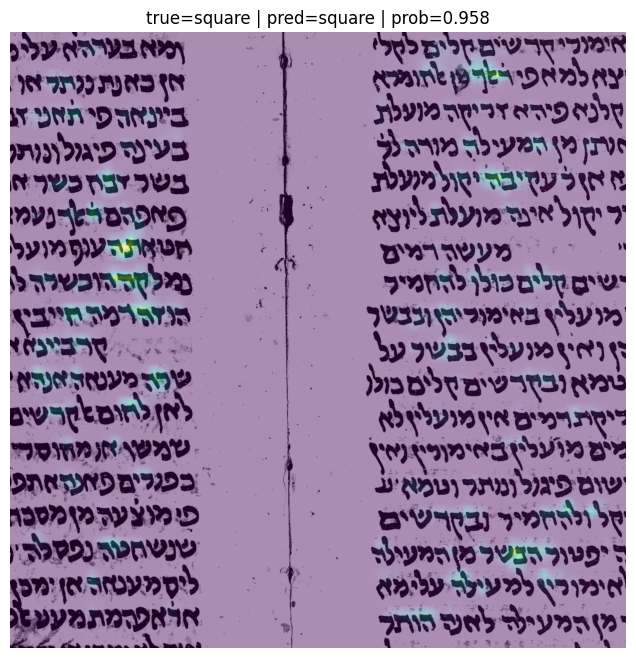

In [25]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_attention(dataset, index=0):
    sample = dataset[index]
    batch = collate_variable_size([sample])
    x = batch['image'].to(device)
    mask = batch['mask'].to(device)
    logits, att = model(x, mask)
    prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred = prob.argmax()

    img = batch['image'][0].cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    h, w = sample['image'].shape[-2:]
    img = img[:h, :w]

    att_map = att[0].float().cpu().numpy()
    att_resized = np.array(Image.fromarray(att_map).resize((w, h), Image.BILINEAR))
    att_resized = att_resized / (att_resized.max() + 1e-8)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.imshow(att_resized, alpha=0.45)
    plt.axis('off')
    plt.title(f"true={sample['label_name']} | pred={idx_to_class[pred]} | prob={prob[pred]:.3f}")
    plt.show()

visualize_attention(test_ds, index=149)


## 13. Save correct attention heatmaps by source class

Run this after the test evaluation cells. It searches the full raw-image dataframe for correctly predicted samples and saves heatmap-overlaid images grouped by the original HSCD source class.


In [26]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image

SOURCE_CLASS_NAMES = sorted(all_df.source_label_name.unique())
HEATMAP_ROOT = OUT_DIR / 'correct_attention_heatmaps_by_source_class'
HEATMAP_ROOT.mkdir(parents=True, exist_ok=True)

all_eval_df = all_df.reset_index(drop=True)
all_eval_ds = HSCDTextRegionDataset(all_eval_df, train=False, max_height=IMG_CROP_MAX_HEIGHT, max_width=IMG_CROP_MAX_WIDTH)


def safe_dir_name(name):
    return str(name).replace('/', '_').replace(' ', '_')


def crop_attention_to_valid_image_area(att_map, pixel_mask, out_w, out_h):
    # The model attention grid includes padded cells.
    # Crop those padded cells away before resizing to the real image size.
    att_map = att_map.float().cpu()

    if pixel_mask.ndim == 2:
        pixel_mask = pixel_mask.unsqueeze(0).unsqueeze(0)
    elif pixel_mask.ndim == 3:
        pixel_mask = pixel_mask.unsqueeze(1)

    feat_h, feat_w = att_map.shape[-2:]

    feat_mask = F.interpolate(
        pixel_mask.float(),
        size=(feat_h, feat_w),
        mode='nearest',
    )[0, 0].bool().cpu().numpy()

    att_np = att_map.numpy()

    valid_y = np.where(feat_mask.any(axis=1))[0]
    valid_x = np.where(feat_mask.any(axis=0))[0]

    if len(valid_y) > 0 and len(valid_x) > 0:
        y0, y1 = int(valid_y.min()), int(valid_y.max()) + 1
        x0, x1 = int(valid_x.min()), int(valid_x.max()) + 1
        att_np = att_np[y0:y1, x0:x1]

    att_np = att_np - att_np.min()
    att_np = att_np / (att_np.max() + 1e-8)

    return np.array(Image.fromarray(att_np).resize((out_w, out_h), Image.BILINEAR))


@torch.no_grad()
def attention_overlay(dataset, index):
    sample = dataset[index]
    batch = collate_variable_size([sample])

    x = batch['image'].to(device)
    mask = batch['mask'].to(device)

    logits, att = model(x, mask)
    prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred = int(prob.argmax())
    square_prob = float(prob[class_to_idx['square']])

    h, w = sample['image'].shape[-2:]

    img = sample['image'].cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    att_resized = crop_attention_to_valid_image_area(
        att_map=att[0],
        pixel_mask=batch['mask'][0],
        out_w=w,
        out_h=h,
    )

    return img, att_resized, pred, square_prob, sample


model.eval()
summary_rows = []
saved_rows = []

for class_i, source_label in enumerate(SOURCE_CLASS_NAMES):
    class_dir = HEATMAP_ROOT / safe_dir_name(source_label)
    class_dir.mkdir(parents=True, exist_ok=True)

    candidates = all_eval_df.index[
        all_eval_df.source_label_name.eq(source_label)
    ].to_numpy().copy()

    rng = np.random.default_rng(SEED + class_i)
    rng.shuffle(candidates)

    saved_for_class = 0
    checked_for_class = 0

    for dataset_index in candidates:
        checked_for_class += 1

        img, att_resized, pred_idx, square_prob, sample = attention_overlay(
            all_eval_ds,
            int(dataset_index),
        )

        true_idx = int(sample['label'])
        if pred_idx != true_idx:
            continue

        saved_for_class += 1

        title = (
            f"{source_label} | true={sample['label_name']} | "
            f"pred={idx_to_class[pred_idx]} | "
            f"idx={int(dataset_index)} | p_square={square_prob:.3f}"
        )

        out_path = class_dir / f"{saved_for_class:02d}_idx_{int(dataset_index)}.png"

        fig, ax = plt.subplots(figsize=(7, 9))
        ax.imshow(img)
        ax.imshow(att_resized, alpha=0.45, cmap='viridis')
        ax.axis('off')
        ax.set_title(title, fontsize=9)
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
        plt.close(fig)

        saved_rows.append({
            'source_label': source_label,
            'dataset_index': int(dataset_index),
            'path': sample['path'],
            'true': sample['label_name'],
            'pred': idx_to_class[pred_idx],
            'p_square': square_prob,
            'heatmap_path': str(out_path),
        })

        if saved_for_class >= 5:
            break

    print(
        f"{source_label}: saved {saved_for_class}/5 correctly predicted samples "
        f"after checking {checked_for_class}"
    )

    summary_rows.append({
        'source_label': source_label,
        'candidates': int(len(candidates)),
        'checked': int(checked_for_class),
        'saved': int(saved_for_class),
    })

saved_heatmaps_df = pd.DataFrame(saved_rows)
heatmap_summary_df = pd.DataFrame(summary_rows)

saved_heatmaps_df.to_csv(HEATMAP_ROOT / 'saved_heatmaps_manifest.csv', index=False)
heatmap_summary_df.to_csv(HEATMAP_ROOT / 'summary.csv', index=False)

print('Saved heatmaps root:', HEATMAP_ROOT)
display(heatmap_summary_df)
display(saved_heatmaps_df.head())


ashkenazic_cursive: saved 5/5 correctly predicted samples after checking 5
ashkenazic_semicursive: saved 5/5 correctly predicted samples after checking 5
ashkenazic_square: saved 5/5 correctly predicted samples after checking 5
byzantine_semicursive: saved 5/5 correctly predicted samples after checking 5
byzantine_square: saved 5/5 correctly predicted samples after checking 5
italian_cursive: saved 5/5 correctly predicted samples after checking 5
italian_semicursive: saved 5/5 correctly predicted samples after checking 6
italian_square: saved 5/5 correctly predicted samples after checking 5
oriental_semicursive: saved 5/5 correctly predicted samples after checking 8
oriental_square: saved 5/5 correctly predicted samples after checking 5
sefardic_cursive: saved 5/5 correctly predicted samples after checking 5
sefardic_semicursive: saved 5/5 correctly predicted samples after checking 5
sefardic_square: saved 5/5 correctly predicted samples after checking 5
yemenite_square: saved 5/5 corr

,source_label,candidates,checked,saved
0,ashkenazic_cursive,15,5,5
1,ashkenazic_semicursive,694,5,5
2,ashkenazic_square,366,5,5
3,byzantine_semicursive,371,5,5
4,byzantine_square,36,5,5
5,italian_cursive,48,5,5
6,italian_semicursive,1182,6,5
7,italian_square,78,5,5
8,oriental_semicursive,198,8,5
9,oriental_square,32,5,5


,source_label,dataset_index,path,true,pred,p_square,heatmap_path
0,ashkenazic_cursive,3105,hscd/images/990001279930205171_IE50379818_P000...,non_square,non_square,0.058633,hscd_convnext_binary_square_raw_image_crop2500...
1,ashkenazic_cursive,3106,hscd/images/990001279930205171_IE50379818_P000...,non_square,non_square,0.051507,hscd_convnext_binary_square_raw_image_crop2500...
2,ashkenazic_cursive,4502,hscd/images/990001749030205171_IE212664041_P00...,non_square,non_square,0.054080,hscd_convnext_binary_square_raw_image_crop2500...
3,ashkenazic_cursive,2373,hscd/images/990001117530205171_IE16691657_P000...,non_square,non_square,0.045061,hscd_convnext_binary_square_raw_image_crop2500...
4,ashkenazic_cursive,1494,hscd/images/990000851190205171_IE69952564_P000...,non_square,non_square,0.065432,hscd_convnext_binary_square_raw_image_crop2500...
